In [4]:
!pip install paho-mqtt

import paho.mqtt.client as mqtt
import json
from google.colab import userdata

# Callback function for when a message is received
def on_message(client, userdata, msg):
    try:
        data = json.loads(msg.payload.decode())

        # Extract values with lowercase field names
        temperature = data.get("temperature", "N/A")
        humidity = data.get("humidity", "N/A")
        print(f"Temperature: {temperature}°C, Humidity: {humidity}%")

    except json.JSONDecodeError:
        print("Received invalid JSON data")

# MQTT setup
broker = "io.adafruit.com"
username = "braude5"
aio_key = userdata.get('AIO_KEY') # Retrieve API key securely
topic = f"{username}/feeds/json"

client = mqtt.Client()
client.username_pw_set(username,aio_key)
client.on_message = on_message

client.connect(broker, 1883, 60)
client.subscribe(topic)

print(f"Subscribed to MQTT topic: {topic}")
client.loop_forever()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.2/67.2 kB 3.5 MB/s eta 0:00:00


/tmp/ipykernel_12303/513131245.py:25: DeprecationWarning: Callback API version 1 is deprecated, update to latest version
  client = mqtt.Client()


Subscribed to MQTT topic: braude5/feeds/json
Temperature: 24.5°C, Humidity: 44.0%
Temperature: 24.5°C, Humidity: 44.0%
Temperature: 24.8°C, Humidity: 46.0%
Temperature: 26.2°C, Humidity: 66.0%


KeyboardInterrupt: 

In [5]:
import requests
from google.colab import userdata

USERNAME = "braude5"
AIO_KEY = userdata.get('AIO_KEY') # Retrieve API key securely
FEED = "temperature"

url = f"https://io.adafruit.com/api/v2/{USERNAME}/feeds/{FEED}/data"
headers = {"X-AIO-Key": AIO_KEY}

response = requests.get(url, headers=headers)
data = response.json()

for item in data[:5]:  # חמשת הנתונים האחרונים
    print(f"Value: {item['value']}, Time: {item['created_at']}")

Value: 24.70, Time: 2026-05-11T08:52:19Z
Value: 24.70, Time: 2026-05-11T08:52:09Z
Value: 25.00, Time: 2026-05-11T08:51:59Z
Value: 25.40, Time: 2026-05-11T08:51:49Z
Value: 26.00, Time: 2026-05-11T08:51:39Z


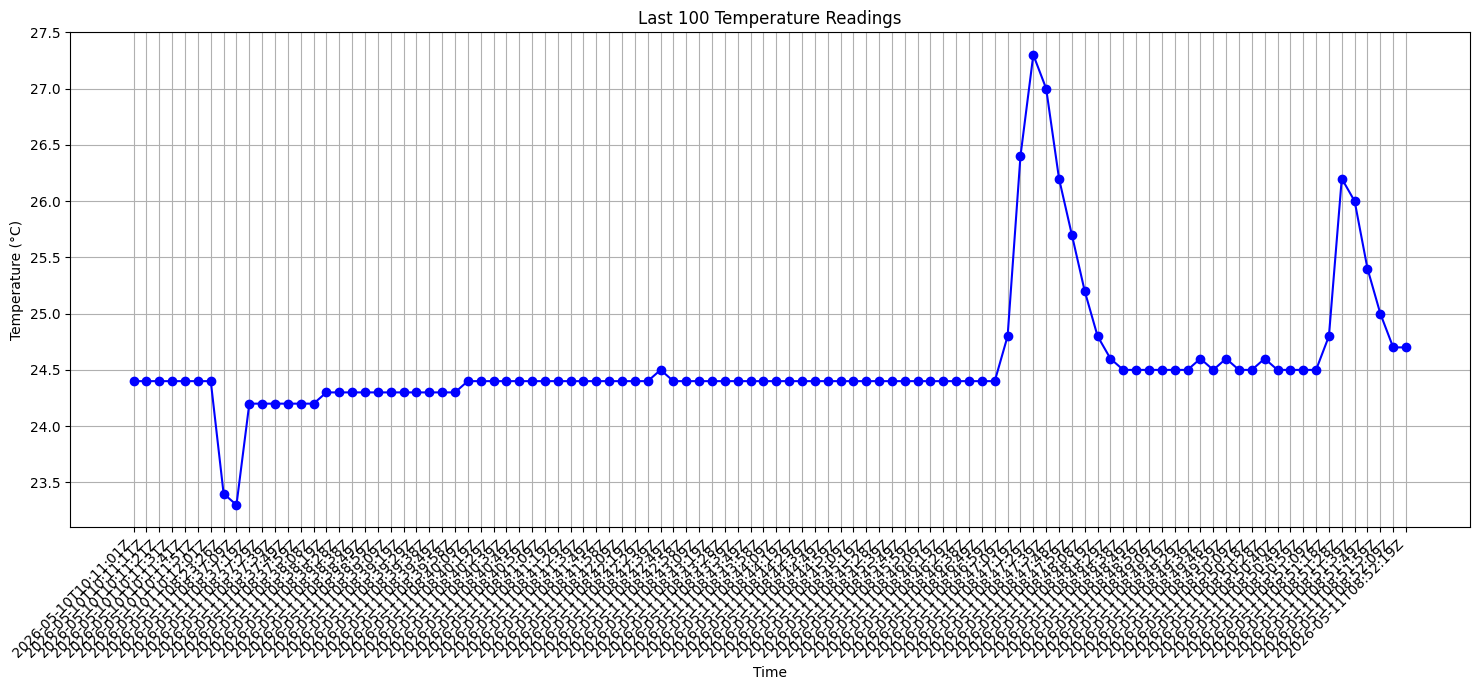

In [6]:
import matplotlib.pyplot as plt

# Extract the last 100 temperature values and their timestamps
# Assuming 'data' contains the fetched information from Adafruit IO

# Ensure we have enough data points
num_points = min(100, len(data))
recent_data = data[:num_points]

temperatures = [float(item['value']) for item in recent_data]
timestamps = [item['created_at'] for item in recent_data]

# Convert timestamps to a more readable format for plotting if needed
# For simplicity, we can plot them as strings or convert to datetime objects
# For better visualization, we should sort them by time if they are not already

# Reverse the lists to have the oldest data on the left of the graph
temperatures.reverse()
timestamps.reverse()

plt.figure(figsize=(15, 7))
plt.plot(timestamps, temperatures, marker='o', linestyle='-', color='b')
plt.xlabel('Time')
plt.ylabel('Temperature (°C)')
plt.title(f'Last {num_points} Temperature Readings')
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()
plt.show()